In [1]:
import json
from matplotlib import font_manager
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import pandas as pd
import os
from scipy.stats import ttest_ind, mannwhitneyu
import warnings

warnings.filterwarnings(
    "ignore", category=UserWarning, message="FixedFormatter should only be used together with FixedLocator"
)

In [2]:
def setup_noto_serif():
    noto_path = "./fonts/NotoSerif-Regular.ttf"
    if not os.path.exists(noto_path):
        raise FileNotFoundError("Noto Serif font not found at ./fonts/NotoSerif-Regular.ttf.")
    font_manager.fontManager.addfont(noto_path)
    font_prop = font_manager.FontProperties(fname=noto_path)
    plt.rcParams['font.family'] = font_prop.get_name()
    return font_prop

def load_baseline_f1_scores(scenario, dataset_id):
    suffix = 'ps' if scenario == 'multilabel' else ''
    filename = f'./results/baseline/{dataset_id}{suffix}/automl_autogluon.json'
    with open(filename, 'r') as file:
        data = json.load(file)
    f1_scores = np.round([x['f1_score_weighted'] for x in data['results']], 3)
    best_f1 = np.max(f1_scores)
    mean_time = np.floor(np.mean([x['training_time'] for x in data['results']]))
    print(dataset_id, '[BASELINE ]', 'best_f1', best_f1, 'mean_time', mean_time)
    return f1_scores, best_f1, mean_time

def load_optimized_f1_scores(dataset_id, baseline_best_f1=None, baseline_mean_time=None, filter_better_than_baseline=True):
    df = pd.read_csv(f'./results/optimized/optuna_openml_{dataset_id}.csv')
    df = df.loc[df['value'] != -1]
    df = df.loc[~df['value'].isna()]
    df = df.loc[df['state'] == 'COMPLETE']
    df = df.loc[(df['oversampling_threshold'] != '0') | (df['undersampling_threshold'] != '0')]

    if filter_better_than_baseline and baseline_best_f1 is not None and baseline_mean_time is not None:
        df = df.loc[
            (df['value'] > baseline_best_f1) |
            ((np.isclose(df['value'], baseline_best_f1)) & (df['total_time'] < baseline_mean_time))
        ]
        print(dataset_id, '[OPTIMIZED]', len(df), 'trials better than baseline')
    else:
        print(dataset_id, '[OPTIMIZED]', len(df), 'valid trials (no baseline filtering)')

    mean_time = round(df['total_time'].mean(), 2) if not df.empty else float('nan')
    best_f1 = round(df['value'].max(), 3) if not df.empty else float('nan')

    return df['value'].to_numpy(), best_f1, mean_time

In [3]:
from scipy.stats import shapiro, normaltest, levene, mannwhitneyu, ttest_ind

def choose_normality_test(n):
    if n < 3:
        return 'none', 'n < 3 → no test'
    elif n < 20:
        return 'shapiro', 'n < 20 → Shapiro-Wilk'
    elif n < 5000:
        return 'dagostino', 'n < 5000 → D’Agostino\'s K²'
    else:
        return 'dagostino', 'n >= 5000 → D’Agostino\'s K² (large sample)'

def run_normality_test(scores, label):
    try:
        if scores is None or len(scores) < 3:
            raise ValueError("Too few samples for any normality test")

        test_type, reason = choose_normality_test(len(scores))

        if test_type == 'shapiro':
            stat, p = shapiro(scores)
            test_name = 'Shapiro-Wilk'
        elif test_type == 'dagostino':
            stat, p = normaltest(scores)
            test_name = "D'Agostino's K²"
        else:
            raise ValueError("No valid test for this sample size")

        is_normal = p >= 0.05
        print(f"{label}: {test_name} test, p = {p:.4f}, {'normal' if is_normal else 'not normal'}")
        return test_name, p, is_normal, reason

    except Exception as e:
        print(f"{label}: Normality test error:", e)
        return 'N/A', 'N/A', None, 'error or too few samples'

def check_variance_equality(baseline, optimized, alpha=0.05):
    try:
        stat, p = levene(baseline, optimized)
        return p >= alpha  # True = equal variances
    except Exception as e:
        print("Levene’s test error:", e)
        return None

def run_statistical_test(baseline_scores, optimized_scores,
                         baseline_is_normal, optimized_is_normal,
                         alpha=0.05, label=""):
    try:
        if (
            baseline_scores is None or optimized_scores is None or
            len(baseline_scores) < 3 or len(optimized_scores) < 3
        ):
            raise ValueError("Insufficient samples for statistical test.")

        both_normal = baseline_is_normal and optimized_is_normal

        if both_normal:
            variances_equal = check_variance_equality(baseline_scores, optimized_scores, alpha)
            if variances_equal:
                t_stat, p_val = ttest_ind(baseline_scores, optimized_scores, equal_var=True)
                test_name = "Student’s t-test"
                reason = "both normal, equal variances"
                stat = t_stat
            else:
                t_stat, p_val = ttest_ind(baseline_scores, optimized_scores, equal_var=False)
                test_name = "Welch’s t-test"
                reason = "both normal, unequal variances"
                stat = t_stat
        else:
            u_stat, p_val = mannwhitneyu(baseline_scores, optimized_scores, alternative='two-sided')
            test_name = "Mann-Whitney U"
            reason = "at least one not normal"
            stat = u_stat

        is_significant = p_val < alpha
        print(label, test_name, 'statistic:', stat, 'p-value:', p_val)
        return test_name, stat, p_val, str(is_significant), reason

    except Exception as e:
        print(label, 'Statistical test error:', e)
        return 'N/A', 'N/A', 'N/A', 'N/A', 'error or too few samples'

In [4]:
from scipy.stats import rankdata

def choose_effect_size_test(baseline_scores, optimized_scores, baseline_is_normal, optimized_is_normal, variances_equal):
    if baseline_is_normal and optimized_is_normal:
        if variances_equal:
            return 'cohen_d', 'both normal, equal variances'
        else:
            return 'welch_d', 'both normal, unequal variances (Welch-adjusted Cohen’s d)'
    else:
        return 'cliffs_delta', 'at least one not normal → non-parametric effect size'

def compute_cohens_d(baseline, optimized, use_pooled_var=True):
    n1, n2 = len(baseline), len(optimized)
    mean1, mean2 = np.mean(baseline), np.mean(optimized)
    var1, var2 = np.var(baseline, ddof=1), np.var(optimized, ddof=1)

    if use_pooled_var:
        pooled_std = np.sqrt(((n1 - 1)*var1 + (n2 - 1)*var2) / (n1 + n2 - 2))
    else:  # Welch-style
        pooled_std = np.sqrt((var1 + var2) / 2)

    if pooled_std == 0:
        return 0.0  # Avoid division by zero

    return (mean1 - mean2) / pooled_std

def compute_cliffs_delta(baseline, optimized):
    n1, n2 = len(baseline), len(optimized)
    all_pairs = [(x, y) for x in baseline for y in optimized]
    gt = sum(1 for x, y in all_pairs if x > y)
    lt = sum(1 for x, y in all_pairs if x < y)
    delta = (gt - lt) / (n1 * n2)
    return delta

def interpret_effect_size(effect_type, effect_value):
    if effect_value == 'N/A' or effect_value is None:
        return 'N/A'
    value = abs(effect_value)
    
    if effect_type == 'cliffs_delta':
        if value < 0.147:
            return 'negligible'
        elif value < 0.33:
            return 'small'
        elif value < 0.474:
            return 'medium'
        else:
            return 'large'
    elif effect_type in ['cohen_d', 'welch_d']:
        if value < 0.2:
            return 'negligible'
        elif value < 0.5:
            return 'small'
        elif value < 0.8:
            return 'medium'
        else:
            return 'large'
    return 'N/A'

In [5]:
font_prop = setup_noto_serif()

In [6]:
datasets = {
    "binary": [
        "31", "37", "44", "1462", "1479", "1510", "40945"
    ],
    "multiclass": [
        "23", "36", "54", "181", "1466", "40691", "40975"
    ],
    "multilabel": [
        "285", "41464", "41465", "41468", "41470", "41471", "41473"
    ]
}

In [7]:
results_dict = {}
alpha = 0.05  # significance level

for scenario, dataset_refs in datasets.items():

    results_dict[scenario] = {}

    for dataset_ref in dataset_refs:

        results_dict[scenario][dataset_ref] = {}
        baseline_scores = None
        optimized_scores = None
        baseline_best_f1 = None
        baseline_mean_time = None

        # Load baseline
        try:
            baseline_scores, baseline_best_f1, baseline_mean_time = \
                load_baseline_f1_scores(scenario, dataset_ref)

            results_dict[scenario][dataset_ref]['baseline_samples'] = len(baseline_scores)
            results_dict[scenario][dataset_ref]['baseline_best_f1'] = baseline_best_f1
            results_dict[scenario][dataset_ref]['baseline_mean_time'] = baseline_mean_time

        except FileNotFoundError as e:
            print('Baseline not found:', e)

        # Load optimized
        try:
            optimized_scores, optimized_best_f1, optimized_mean_time = \
                load_optimized_f1_scores(dataset_ref, baseline_best_f1, baseline_mean_time)

            results_dict[scenario][dataset_ref]['optimized_samples'] = len(optimized_scores)
            results_dict[scenario][dataset_ref]['optimized_best_f1'] = optimized_best_f1
            results_dict[scenario][dataset_ref]['optimized_mean_time'] = optimized_mean_time

        except FileNotFoundError as e:
            print('Optimized results not found:', e)

        # Normality tests (adaptive)
        test_base_name, sw_p_base, sw_is_normal_base, base_reason = run_normality_test(baseline_scores, f"{dataset_ref} [BASELINE]")
        test_opt_name, sw_p_opt, sw_is_normal_opt, opt_reason = run_normality_test(optimized_scores, f"{dataset_ref} [OPTIMIZED]")

        results_dict[scenario][dataset_ref]['baseline_normality_reason'] = base_reason
        results_dict[scenario][dataset_ref]['baseline_normality_test'] = test_base_name
        results_dict[scenario][dataset_ref]['baseline_normality_p'] = sw_p_base
        results_dict[scenario][dataset_ref]['baseline_is_normal'] = sw_is_normal_base

        results_dict[scenario][dataset_ref]['optimized_normality_test'] = test_opt_name
        results_dict[scenario][dataset_ref]['optimized_normality_p'] = sw_p_opt
        results_dict[scenario][dataset_ref]['optimized_is_normal'] = sw_is_normal_opt
        results_dict[scenario][dataset_ref]['optimized_normality_reason'] = opt_reason

        # Precompute variance equality once
        variances_equal = check_variance_equality(baseline_scores, optimized_scores)

        # Adaptive statistical test
        test_name, test_stat, p_value, significant, stat_reason = run_statistical_test(
            baseline_scores,
            optimized_scores,
            baseline_is_normal=bool(sw_is_normal_base),
            optimized_is_normal=bool(sw_is_normal_opt),
            alpha=alpha,
            label=dataset_ref
        )

        results_dict[scenario][dataset_ref]['test_used'] = test_name
        results_dict[scenario][dataset_ref]['test_stat'] = test_stat
        results_dict[scenario][dataset_ref]['stat_test_reason'] = stat_reason
        results_dict[scenario][dataset_ref]['p_value'] = p_value
        results_dict[scenario][dataset_ref]['alpha'] = alpha
        results_dict[scenario][dataset_ref]['p_value < alpha'] = significant
        results_dict[scenario][dataset_ref]['significant'] = significant

        # Effect size calculation
        effect_test, effect_reason = choose_effect_size_test(
            baseline_scores, optimized_scores,
            baseline_is_normal=bool(sw_is_normal_base),
            optimized_is_normal=bool(sw_is_normal_opt),
            variances_equal=variances_equal
        )
        
        try:
            if effect_test == 'cliffs_delta':
                effect_value = round(compute_cliffs_delta(baseline_scores, optimized_scores), 4)
            elif effect_test == 'cohen_d':
                effect_value = round(compute_cohens_d(baseline_scores, optimized_scores, use_pooled_var=True), 4)
            elif effect_test == 'welch_d':
                effect_value = round(compute_cohens_d(baseline_scores, optimized_scores, use_pooled_var=False), 4)
            else:
                effect_value = 'N/A'
        except Exception as e:
            print(f"Effect size calculation error for {dataset_ref}:", e)
            effect_value = 'N/A'
        
        effect_interpretation = interpret_effect_size(effect_test, effect_value)
        
        results_dict[scenario][dataset_ref]['effect_size_type'] = effect_test
        results_dict[scenario][dataset_ref]['effect_size_reason'] = effect_reason
        results_dict[scenario][dataset_ref]['effect_size_value'] = effect_value
        results_dict[scenario][dataset_ref]['effect_size_interpretation'] = effect_interpretation

        print()

31 [BASELINE ] best_f1 0.787 mean_time 10.0
31 [OPTIMIZED] 26 trials better than baseline
31 [BASELINE]: D'Agostino's K² test, p = 0.8757, normal
31 [OPTIMIZED]: D'Agostino's K² test, p = 0.0000, not normal
31 Mann-Whitney U statistic: 0.0 p-value: 4.1327566255825505e-09

37 [BASELINE ] best_f1 0.804 mean_time 22.0
37 [OPTIMIZED] 378 trials better than baseline
37 [BASELINE]: D'Agostino's K² test, p = 0.9542, normal
37 [OPTIMIZED]: D'Agostino's K² test, p = 0.0000, not normal
37 Mann-Whitney U statistic: 0.0 p-value: 4.045317559645937e-14

44 [BASELINE ] best_f1 0.966 mean_time 80.0
44 [OPTIMIZED] 865 trials better than baseline
44 [BASELINE]: D'Agostino's K² test, p = 0.7984, normal
44 [OPTIMIZED]: D'Agostino's K² test, p = 0.0000, not normal
44 Mann-Whitney U statistic: 0.0 p-value: 1.871554860941266e-14

1462 [BASELINE ] best_f1 1.0 mean_time 11.0
1462 [OPTIMIZED] 289 trials better than baseline
1462 [BASELINE]: D'Agostino's K² test, p = 0.1626, normal
1462 [OPTIMIZED]: D'Agostino's

C:\Users\marce\anaconda3\envs\AutoMLEvalUtils\lib\site-packages\scipy\stats\_stats_py.py:1633: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  b2 = skew(a, axis)
C:\Users\marce\anaconda3\envs\AutoMLEvalUtils\lib\site-packages\scipy\stats\_stats_py.py:1738: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  b2 = kurtosis(a, axis, fisher=False)
C:\Users\marce\anaconda3\envs\AutoMLEvalUtils\lib\site-packages\scipy\stats\_stats_py.py:1633: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  b2 = skew(a, axis)
C:\Users\marce\anaconda3\envs\AutoMLEvalUtils\lib\site-packages\scipy\stats\_stats_py.py:1738: RuntimeWarning: Precision 

In [8]:
# New column order including normality test names, statistical test, and effect size info
col_order = [
    'scenario', 'id',

    # Baseline info
    'baseline_samples', 'baseline_best_f1', 'baseline_mean_time',
    'baseline_normality_test', 'baseline_normality_reason', 'baseline_normality_p', 'baseline_is_normal',

    # Optimized info
    'optimized_samples', 'optimized_best_f1', 'optimized_mean_time',
    'optimized_normality_test', 'optimized_normality_reason', 'optimized_normality_p', 'optimized_is_normal',

    # Statistical test
    'test_used', 'stat_test_reason', 'test_stat',
    'p_value', 'alpha', 'p_value < alpha', 'significant',

    # Effect size
    'effect_size_type', 'effect_size_reason', 'effect_size_value', 'effect_size_interpretation'
]

# Flatten results_dict into a DataFrame
result_dfs = []
for scenario, dataset_dict in results_dict.items():
    df = pd.DataFrame.from_dict(dataset_dict, orient='index')
    df = df.assign(scenario=scenario, id=list(dataset_dict.keys()))
    result_dfs.append(df)

# Concatenate and reorder columns
summary_df = pd.concat(result_dfs, ignore_index=True)[col_order]

# Display result
display(summary_df)

,scenario,id,baseline_samples,baseline_best_f1,baseline_mean_time,baseline_normality_test,baseline_normality_reason,baseline_normality_p,baseline_is_normal,optimized_samples,...,stat_test_reason,test_stat,p_value,alpha,p_value < alpha,significant,effect_size_type,effect_size_reason,effect_size_value,effect_size_interpretation
0,binary,31,20.0,0.787,10.0,D'Agostino's K²,n < 5000 → D’Agostino's K²,0.875678,True,26,...,at least one not normal,0.0,0.0,0.05,True,True,cliffs_delta,at least one not normal → non-parametric effec...,-1.0,large
1,binary,37,20.0,0.804,22.0,D'Agostino's K²,n < 5000 → D’Agostino's K²,0.954233,True,378,...,at least one not normal,0.0,0.0,0.05,True,True,cliffs_delta,at least one not normal → non-parametric effec...,-1.0,large
2,binary,44,20.0,0.966,80.0,D'Agostino's K²,n < 5000 → D’Agostino's K²,0.798369,True,865,...,at least one not normal,0.0,0.0,0.05,True,True,cliffs_delta,at least one not normal → non-parametric effec...,-1.0,large
3,binary,1462,20.0,1.000,11.0,D'Agostino's K²,n < 5000 → D’Agostino's K²,0.162559,True,289,...,at least one not normal,867.0,0.0,0.05,True,True,cliffs_delta,at least one not normal → non-parametric effec...,-0.7,large
4,binary,1479,20.0,0.926,17.0,D'Agostino's K²,n < 5000 → D’Agostino's K²,0.00055,False,90,...,at least one not normal,0.0,0.0,0.05,True,True,cliffs_delta,at least one not normal → non-parametric effec...,-1.0,large
5,binary,1510,20.0,1.000,6.0,D'Agostino's K²,n < 5000 → D’Agostino's K²,0.767355,True,1,...,error or too few samples,N/A,N/A,0.05,N/A,N/A,cliffs_delta,at least one not normal → non-parametric effec...,-0.95,large
6,binary,40945,20.0,0.981,8.0,D'Agostino's K²,n < 5000 → D’Agostino's K²,0.080503,True,294,...,at least one not normal,0.0,0.0,0.05,True,True,cliffs_delta,at least one not normal → non-parametric effec...,-1.0,large
7,multiclass,23,20.0,0.615,17.0,D'Agostino's K²,n < 5000 → D’Agostino's K²,0.257606,True,108,...,at least one not normal,0.0,0.0,0.05,True,True,cliffs_delta,at least one not normal → non-parametric effec...,-1.0,large
8,multiclass,36,20.0,0.991,87.0,D'Agostino's K²,n < 5000 → D’Agostino's K²,0.779068,True,245,...,at least one not normal,0.0,0.0,0.05,True,True,cliffs_delta,at least one not normal → non-parametric effec...,-1.0,large
9,multiclass,54,20.0,0.850,17.0,D'Agostino's K²,n < 5000 → D’Agostino's K²,0.712707,True,65,...,at least one not normal,0.0,0.0,0.05,True,True,cliffs_delta,at least one not normal → non-parametric effec...,-1.0,large


In [9]:
def highlight_filter_reason(row):
    reason = str(row['filter_reason']).lower()
    significance = str(row.get('significant', '')).lower()

    # Prioritize red (data issues), then green (perfect baseline), then yellow (not significant)
    if 'too few' in reason or 'missing' in reason:
        style = 'background-color: lightcoral; color: black'
    elif 'perfect baseline f1' in reason:
        style = 'background-color: lightgreen; color: black'
    elif significance == 'false':
        style = 'background-color: lightyellow; color: black'
    else:
        style = ''

    return [style] * len(row)

In [10]:
# Define which columns to blank when filtering applies
stat_columns = [
    'baseline_normality_p', 'baseline_is_normal',
    'optimized_normality_p', 'optimized_is_normal',
    'test_used', 'stat_test_reason', 'test_stat',
    'p_value', 'alpha', 'p_value < alpha', 'significant',
    'effect_size_type', 'effect_size_reason', 'effect_size_value', 'effect_size_interpretation'  # ← New
]

# Copy and initialize
filtered_df = summary_df.copy()
filtered_df['filter_reason'] = ''

# Build masks
perfect_baseline_mask = filtered_df['baseline_best_f1'] == 1.0
few_baseline_mask = filtered_df['baseline_samples'].isna() | (filtered_df['baseline_samples'].astype(float) < 3)
few_optimized_mask = filtered_df['optimized_samples'].isna() | (filtered_df['optimized_samples'].astype(float) < 3)

# Combine all masks
any_filter_mask = perfect_baseline_mask | few_optimized_mask | few_baseline_mask

# Apply blanking to statistical and effect size result columns
filtered_df.loc[any_filter_mask, stat_columns] = 'N/A'

# Build filter reason incrementally
filtered_df['filter_reason'] = ''
filtered_df.loc[perfect_baseline_mask, 'filter_reason'] += 'Perfect baseline F1; '
filtered_df.loc[few_baseline_mask, 'filter_reason'] += 'Too few baseline samples (<3); '
filtered_df.loc[few_optimized_mask, 'filter_reason'] += 'Too few optimized samples (<3); '

# Clean up trailing punctuation
filtered_df['filter_reason'] = filtered_df['filter_reason'].str.rstrip('; ').replace('', 'None')

filtered_df.to_csv('artifacts/stats/valid_trials.csv')
filtered_df.to_excel('artifacts/stats/valid_trials.xlsx')

# Apply row-level styling
styled_df = filtered_df.style.apply(highlight_filter_reason, axis=1)

styled_df.to_html('artifacts/stats/valid_trials.html')

display(styled_df)

,scenario,id,baseline_samples,baseline_best_f1,baseline_mean_time,baseline_normality_test,baseline_normality_reason,baseline_normality_p,baseline_is_normal,optimized_samples,optimized_best_f1,optimized_mean_time,optimized_normality_test,optimized_normality_reason,optimized_normality_p,optimized_is_normal,test_used,stat_test_reason,test_stat,p_value,alpha,p_value < alpha,significant,effect_size_type,effect_size_reason,effect_size_value,effect_size_interpretation,filter_reason
0,binary,31,20.000000,0.787000,10.000000,D'Agostino's K²,n < 5000 → D’Agostino's K²,0.875678,True,26,0.802000,7.840000,D'Agostino's K²,n < 5000 → D’Agostino's K²,0.000000,False,Mann-Whitney U,at least one not normal,0.000000,0.000000,0.050000,True,True,cliffs_delta,at least one not normal → non-parametric effect size,-1.000000,large,None
1,binary,37,20.000000,0.804000,22.000000,D'Agostino's K²,n < 5000 → D’Agostino's K²,0.954233,True,378,0.850000,13.300000,D'Agostino's K²,n < 5000 → D’Agostino's K²,0.000000,False,Mann-Whitney U,at least one not normal,0.000000,0.000000,0.050000,True,True,cliffs_delta,at least one not normal → non-parametric effect size,-1.000000,large,None
2,binary,44,20.000000,0.966000,80.000000,D'Agostino's K²,n < 5000 → D’Agostino's K²,0.798369,True,865,0.982000,121.760000,D'Agostino's K²,n < 5000 → D’Agostino's K²,0.000000,False,Mann-Whitney U,at least one not normal,0.000000,0.000000,0.050000,True,True,cliffs_delta,at least one not normal → non-parametric effect size,-1.000000,large,None
3,binary,1462,20.000000,1.000000,11.000000,D'Agostino's K²,n < 5000 → D’Agostino's K²,N/A,N/A,289,1.000000,9.430000,D'Agostino's K²,n < 5000 → D’Agostino's K²,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,Perfect baseline F1
4,binary,1479,20.000000,0.926000,17.000000,D'Agostino's K²,n < 5000 → D’Agostino's K²,0.000550,False,90,0.934000,43.490000,D'Agostino's K²,n < 5000 → D’Agostino's K²,0.000003,False,Mann-Whitney U,at least one not normal,0.000000,0.000000,0.050000,True,True,cliffs_delta,at least one not normal → non-parametric effect size,-1.000000,large,None
5,binary,1510,20.000000,1.000000,6.000000,D'Agostino's K²,n < 5000 → D’Agostino's K²,N/A,N/A,1,1.000000,5.890000,N/A,error or too few samples,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,Perfect baseline F1; Too few optimized samples (<3)
6,binary,40945,20.000000,0.981000,8.000000,D'Agostino's K²,n < 5000 → D’Agostino's K²,0.080503,True,294,1.000000,4.220000,D'Agostino's K²,n < 5000 → D’Agostino's K²,0.000000,False,Mann-Whitney U,at least one not normal,0.000000,0.000000,0.050000,True,True,cliffs_delta,at least one not normal → non-parametric effect size,-1.000000,large,None
7,multiclass,23,20.000000,0.615000,17.000000,D'Agostino's K²,n < 5000 → D’Agostino's K²,0.257606,True,108,0.647000,37.720000,D'Agostino's K²,n < 5000 → D’Agostino's K²,0.000121,False,Mann-Whitney U,at least one not normal,0.000000,0.000000,0.050000,True,True,cliffs_delta,at least one not normal → non-parametric effect size,-1.000000,large,None
8,multiclass,36,20.000000,0.991000,87.000000,D'Agostino's K²,n < 5000 → D’Agostino's K²,0.779068,True,245,0.994000,18.410000,D'Agostino's K²,n < 5000 → D’Agostino's K²,0.000000,False,Mann-Whitney U,at least one not normal,0.000000,0.000000,0.050000,True,True,cliffs_delta,at least one not normal → non-parametric effect size,-1.000000,large,None
9,multiclass,54,20.000000,0.850000,17.000000,D'Agostino's K²,n < 5000 → D’Agostino's K²,0.712707,True,65,0.854000,10.380000,D'Agostino's K²,n < 5000 → D’Agostino's K²,0.000000,False,Mann-Whitney U,at least one not normal,0.000000,0.000000,0.050000,True,True,cliffs_delta,at least one not normal → non-parametric effect size,-1.000000,large,None


In [11]:
with pd.ExcelWriter(f'artifacts/stats/statistical_tests.xlsx', engine='xlsxwriter') as writer:
    summary_df.to_excel(writer, index=False, sheet_name='Summary')
    workbook = writer.book
    worksheet = writer.sheets['Summary']

    # Define formats
    text_format = workbook.add_format({'num_format': '@'})
    integer_format = workbook.add_format({'num_format': '0'})
    float_3dec_format = workbook.add_format({'num_format': '0.000'})
    float_2dec_format = workbook.add_format({'num_format': '0.00'})
    scientific_format = workbook.add_format({'num_format': '0.00E+00'})

    # Apply formats to columns (A → Z based on updated col_order)
    worksheet.set_column('A:A', None, text_format)          # scenario
    worksheet.set_column('B:B', None, integer_format)       # id

    worksheet.set_column('C:C', None, integer_format)       # baseline_samples
    worksheet.set_column('D:D', None, float_3dec_format)    # baseline_best_f1
    worksheet.set_column('E:E', None, float_2dec_format)    # baseline_mean_time
    worksheet.set_column('F:F', None, text_format)          # baseline_normality_test
    worksheet.set_column('G:G', None, text_format)          # baseline_normality_reason
    worksheet.set_column('H:H', None, scientific_format)    # baseline_normality_p
    worksheet.set_column('I:I', None, text_format)          # baseline_is_normal

    worksheet.set_column('J:J', None, integer_format)       # optimized_samples
    worksheet.set_column('K:K', None, float_3dec_format)    # optimized_best_f1
    worksheet.set_column('L:L', None, float_2dec_format)    # optimized_mean_time
    worksheet.set_column('M:M', None, text_format)          # optimized_normality_test
    worksheet.set_column('N:N', None, text_format)          # optimized_normality_reason
    worksheet.set_column('O:O', None, scientific_format)    # optimized_normality_p
    worksheet.set_column('P:P', None, text_format)          # optimized_is_normal

    worksheet.set_column('Q:Q', None, text_format)          # test_used
    worksheet.set_column('R:R', None, text_format)          # stat_test_reason
    worksheet.set_column('S:S', None, scientific_format)    # test_stat
    worksheet.set_column('T:T', None, scientific_format)    # p_value
    worksheet.set_column('U:U', None, float_2dec_format)    # alpha
    worksheet.set_column('V:V', None, text_format)          # p_value < alpha
    worksheet.set_column('W:W', None, text_format)          # significant

    worksheet.set_column('X:X', None, text_format)          # effect_size_type
    worksheet.set_column('Y:Y', None, text_format)          # effect_size_reason
    worksheet.set_column('Z:Z', None, float_3dec_format)    # effect_size_value
    worksheet.set_column('AA:AA', None, text_format)        # effect_size_interpretation

In [12]:
import pandas as pd
import os
import glob

def load_all_valid_trials(optimized_dir="results/optimized/"):
    df_list = []
    for file in glob.glob(os.path.join(optimized_dir, "optuna_openml_*.csv")):
        dataset_id = os.path.basename(file).split("_")[-1].replace(".csv", "")
        df = pd.read_csv(file)

        # Ensure thresholds are strings so we preserve "auto"
        df["oversampling_threshold"] = df.get("oversampling_threshold", "0").astype(str)
        df["undersampling_threshold"] = df.get("undersampling_threshold", "0").astype(str)

        # Filter: must be COMPLETE and valid value, and at least one threshold != "0"
        df = df[
            (df["state"] == "COMPLETE") &
            (df["value"] != -1) &
            (~df["value"].isna()) &
            ((df["oversampling_threshold"] != "0") | (df["undersampling_threshold"] != "0"))
        ].copy()

        df["dataset_id"] = dataset_id
        df_list.append(df)

    if not df_list:
        raise ValueError("No valid trials found.")

    return pd.concat(df_list, ignore_index=True)

# Per-scenario analysis

In [13]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scikit_posthocs as sp

def interpret_effect_size(effect_type, value):
    val = abs(value)
    if effect_type == "Cliff's delta":
        if val < 0.147: return "negligible"
        elif val < 0.33: return "small"
        elif val < 0.474: return "medium"
        else: return "large"
    elif effect_type == "Cohen's d":
        if val < 0.2: return "negligible"
        elif val < 0.5: return "small"
        elif val < 0.8: return "medium"
        else: return "large"
    return "unknown"

def compute_effect_size(group1, group2, assume_normal=True):
    if assume_normal:
        mean1, mean2 = np.mean(group1), np.mean(group2)
        var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
        pooled_sd = np.sqrt((var1 + var2) / 2)
        d = (mean2 - mean1) / pooled_sd if pooled_sd > 0 else 0.0
        return "Cohen's d", round(d, 4), interpret_effect_size("Cohen's d", d)
    else:
        gt = sum(x > y for x in group2 for y in group1)
        lt = sum(x < y for x in group2 for y in group1)
        delta = (gt - lt) / (len(group1) * len(group2))
        return "Cliff's delta", round(delta, 4), interpret_effect_size("Cliff's delta", delta)

def posthoc_sampling_analysis_with_effects(
    valid_trials_df,
    scenario_map,
    alpha=0.05,
    group_by="method",
    top_k=None,
    top_k_metric="mean"  # or "count"
):
    """
    Performs pairwise comparisons of all sampling combinations within each scenario.

    Parameters:
        valid_trials_df (pd.DataFrame): DataFrame of valid optimization trials.
        scenario_map (dict): Maps dataset_id to scenario.
        alpha (float): Significance level.
        group_by (str): "method", "threshold", or "combination" to control grouping.
        top_k (int or None): If set, restricts analysis to top-k configs by metric.
        top_k_metric (str): "mean" = top by mean F1; "count" = top by trial count.

    Returns:
        dict: Result DataFrames per scenario including p-values, effect sizes, and interpretation.
    """
    df = valid_trials_df.copy()
    df["scenario"] = df["dataset_id"].map(scenario_map)

    # Grouping logic
    if group_by == "method":
        df["sampling_config"] = (
            df["oversampling_method"].astype(str) + " + " +
            df["undersampling_method"].astype(str)
        )
    elif group_by == "threshold":
        df["sampling_config"] = (
            df["oversampling_threshold"].astype(str) + " + " +
            df["undersampling_threshold"].astype(str)
        )
    else: # combination
        df["sampling_config"] = (
            df["oversampling_method"].astype(str) + "@" + df["oversampling_threshold"].astype(str) + " + " +
            df["undersampling_method"].astype(str) + "@" + df["undersampling_threshold"].astype(str)
        )

    results_by_scenario = {}

    for scenario in df["scenario"].dropna().unique():
        df_s = df[df["scenario"] == scenario].copy()
        groups = df_s.groupby("sampling_config")["value"].apply(list)

        # Keep only configs with at least 3 trials
        groups = groups[groups.apply(len) >= 3]

        # Select top_k configs by metric
        if top_k is not None and len(groups) > top_k:
            if top_k_metric == "count":
                top_configs = groups.apply(len).sort_values(ascending=False).head(top_k).index
            else:  # top_k_metric == "mean"
                top_configs = groups.apply(np.mean).sort_values(ascending=False).head(top_k).index

            groups = groups.loc[top_configs]
            df_s = df_s[df_s["sampling_config"].isin(groups.index)]

        if len(groups) < 2:
            print(f"Skipping {scenario} ({group_by}) — only {len(groups)} valid config(s).")
            results_by_scenario[scenario] = pd.DataFrame()
            continue

        print(f"Analyzing {scenario} ({group_by}) with {len(groups)} configs...")

        all_scores = []
        all_labels = []
        for config, vals in groups.items():
            all_scores.extend(vals)
            all_labels.extend([config] * len(vals))

        all_normal = all(
            stats.shapiro(vals).pvalue > 0.05 if len(vals) < 5000 else stats.normaltest(vals).pvalue > 0.05
            for vals in groups
        )
        equal_var = stats.levene(*groups.tolist()).pvalue > 0.05

        result_rows = []

        if all_normal and equal_var:
            anova_stat, anova_p = stats.f_oneway(*groups.tolist())
            if anova_p < alpha:
                tukey = pairwise_tukeyhsd(endog=all_scores, groups=all_labels, alpha=alpha)
                for i in range(len(tukey.reject)):
                    g1, g2 = tukey._multicomp.groupsunique[tukey._multicomp.pairindices[i]]
                    if g1 not in groups or g2 not in groups:
                        print(f"Skipping invalid pair: {g1} vs {g2}")
                        continue
                    s1 = groups[g1]
                    s2 = groups[g2]
                    effect_type, effect_value, interpretation = compute_effect_size(s1, s2, assume_normal=True)
                    result_rows.append({
                        "group1": g1,
                        "group2": g2,
                        "p_value": round(tukey.pvalues[i], 4),
                        "reject": tukey.reject[i],
                        "test_used": "ANOVA + Tukey HSD",
                        "effect_type": effect_type,
                        "effect_value": effect_value,
                        "effect_interpretation": interpretation
                    })
        else:
            kruskal_stat, kruskal_p = stats.kruskal(*groups.tolist())
            if kruskal_p < alpha:
                print(f"Kruskal-Wallis p={kruskal_p:.4f} — running posthoc Dunn test.")
                dunn = sp.posthoc_dunn(
                    df_s[df_s["sampling_config"].isin(groups.index)],
                    val_col="value", group_col="sampling_config", p_adjust='holm'
                )
                for i, g1 in enumerate(dunn.columns):
                    for j, g2 in enumerate(dunn.index):
                        if j <= i:
                            continue
                        if g1 not in groups or g2 not in groups:
                            print(f"Skipping invalid pair: {g1} vs {g2}")
                            continue
                        p = dunn.loc[g2, g1]
                        s1 = groups[g1]
                        s2 = groups[g2]
                        effect_type, effect_value, interpretation = compute_effect_size(s1, s2, assume_normal=False)
                        result_rows.append({
                            "group1": g1,
                            "group2": g2,
                            "p_value": round(p, 4),
                            "reject": p < alpha,
                            "test_used": "Kruskal-Wallis + Dunn",
                            "effect_type": effect_type,
                            "effect_value": effect_value,
                            "effect_interpretation": interpretation
                        })
            else:
                print(f"Kruskal-Wallis p={kruskal_p:.4f} — no posthoc testing.")

        result_df = pd.DataFrame(result_rows)
        if not result_df.empty and "p_value" in result_df.columns:
            result_df = result_df.sort_values("p_value")

        if result_df.empty:
            print(f"No pairwise comparisons computed for {scenario} ({group_by})")

        results_by_scenario[scenario] = result_df

    return results_by_scenario

# Method combinations

In [14]:
def build_win_matrix_from_posthoc(results_df, mode="binary", ignore_significance=False):
    configs = sorted(set(results_df["group1"]) | set(results_df["group2"]))
    matrix = pd.DataFrame(0.0, index=configs, columns=configs)

    for _, row in results_df.iterrows():
        g1, g2 = row["group1"], row["group2"]
        if not row["reject"] and not ignore_significance:
            continue

        effect = row["effect_value"]

        if mode == "binary":
            if effect > 0:
                matrix.loc[g1, g2] = 1
            elif effect < 0:
                matrix.loc[g2, g1] = 1
        elif mode == "effect":
            if effect > 0:
                matrix.loc[g1, g2] = abs(effect)
            elif effect < 0:
                matrix.loc[g2, g1] = abs(effect)
        elif mode == "signed_effect":
            if effect > 0:
                matrix.loc[g1, g2] = effect
            elif effect < 0:
                matrix.loc[g2, g1] = effect

    return matrix

In [15]:
def filter_top_n_win_matrix(win_matrix, top_n=10):
    total_wins = win_matrix.sum(axis=1).sort_values(ascending=False)
    top_configs = total_wins.head(top_n).index
    return win_matrix.loc[top_configs, top_configs]

In [16]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import cm
from matplotlib.colors import Normalize

def get_colormap_colors(values, cmap_name="Greens"):
    norm = Normalize(vmin=0, vmax=max(values) if max(values) > 0 else 1)
    cmap = plt.colormaps.get_cmap(cmap_name)
    return [cmap(norm(val)) for val in values]

def map_composite_label(method_mapping, label):
    parts = label.split('+')
    parts[0] = parts[0].strip() + ('over' if parts[0].strip() == 'random' else '')
    parts[1] = parts[1].strip() + ('under' if parts[1].strip() == 'random' else '')
    mapped_parts = [method_mapping.get(p.strip(), p.strip()) for p in parts]
    return ' + '.join(mapped_parts)

def plot_win_loss_heatmap_with_marginals(df_wins, save_path, title="Win–Loss Counts (Row beats Column)", cmap="Spectral", annot=True, float_format=".2f", method_mapping={}):
    # Apply optional name mapping
    try:
        df_wins.index = [map_composite_label(method_mapping, fw) for fw in df_wins.index]
        df_wins.columns = [map_composite_label(method_mapping, fw) for fw in df_wins.columns]
    except NameError:
        pass

    # Compute marginals AFTER renaming
    row_sums = df_wins.sum(axis=1)
    col_sums = df_wins.sum(axis=0)

    row_colors = get_colormap_colors(row_sums.values, cmap_name=cmap)
    col_colors = get_colormap_colors(col_sums.values, cmap_name=cmap)

    # Setup figure layout
    fig = plt.figure(figsize=(20, 10), constrained_layout=True)
    if title:
        fig.suptitle(title, fontsize=16, y=1.02)
    gs = fig.add_gridspec(2, 2, width_ratios=[4, 0.6], height_ratios=[0.6, 4], wspace=0.01, hspace=0.01)

    ax_heatmap = fig.add_subplot(gs[1, 0])
    ax_row_sum = fig.add_subplot(gs[1, 1])
    ax_col_sum = fig.add_subplot(gs[0, 0])

    # Draw main heatmap
    sns.heatmap(
        df_wins,
        annot=annot,
        cmap=cmap,
        fmt=float_format,
        ax=ax_heatmap,
        cbar=False,
        linewidths=0.5,
        linecolor='white',
    )
    plt.setp(ax_heatmap.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

    heatmap_y_centers = np.arange(len(df_wins.index)) + 0.5
    heatmap_x_centers = np.arange(len(df_wins.columns)) + 0.5

    # Row marginals (wins)
    bars = ax_row_sum.barh(
        heatmap_y_centers,
        row_sums.values,
        height=0.8,
        color=row_colors,
        edgecolor='grey'
    )
    for bar in bars:
        width = bar.get_width()
        ax_row_sum.text(
            width + max(row_sums.values) * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{width:{float_format}}",
            va='center',
            fontsize=8
        )

    # Column marginals (losses)
    bars = ax_col_sum.bar(
        heatmap_x_centers,
        col_sums.values,
        width=0.8,
        color=col_colors,
        edgecolor='grey'
    )
    for bar in bars:
        height = bar.get_height()
        ax_col_sum.text(
            bar.get_x() + bar.get_width() / 2,
            height + max(col_sums.values) * 0.02,
            f"  {height:{float_format}}",
            ha='center',
            fontsize=9,
            rotation=90
        )

    # Axes configuration
    # ax_heatmap.set_title(title, pad=25)
    ax_heatmap.set_xlabel("Beaten Config", fontsize=12)
    ax_heatmap.set_ylabel("Winning Config", fontsize=12)

    ax_row_sum.set_ylim(ax_heatmap.get_ylim())
    ax_row_sum.set_yticks([])
    ax_row_sum.set_xlabel("Total Wins", fontsize=12)
    ax_row_sum.spines[['top', 'right', 'left']].set_visible(False)
    ax_row_sum.set_xlim(0, max(row_sums.values) * 1.2)

    ax_col_sum.set_xlim(ax_heatmap.get_xlim())
    ax_col_sum.set_xticks([])
    ax_col_sum.set_ylabel("Total Losses", fontsize=12)
    ax_col_sum.spines[['top', 'right', 'bottom']].set_visible(False)
    ax_col_sum.set_ylim(0, max(col_sums.values) * 1.2)

    # Ensure save directory exists
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

In [17]:
def build_win_matrix_from_posthoc(results_df, mode="binary", ignore_significance=False):
    """
    Build a win/effect matrix from posthoc results.

    Parameters:
        results_df (pd.DataFrame): Output of posthoc_sampling_analysis_with_effects.
        mode (str): 
            - "binary": matrix with 1 if config A significantly beats B
            - "effect": absolute effect size where A beats B
            - "signed_effect": signed effect size where A beats B
        ignore_significance (bool): If True, use all comparisons (not just where reject == True)

    Returns:
        pd.DataFrame: square matrix [config × config] with wins/effects
    """
    configs = sorted(set(results_df["group1"]) | set(results_df["group2"]))
    matrix = pd.DataFrame(0.0, index=configs, columns=configs)

    for _, row in results_df.iterrows():
        g1, g2 = row["group1"], row["group2"]
        reject = row["reject"]
        effect = row["effect_value"]

        if not reject and not ignore_significance:
            continue  # skip unless significance is ignored

        if effect > 0:
            winner, loser = g1, g2
        elif effect < 0:
            winner, loser = g2, g1
        else:
            continue  # effect == 0

        if mode == "binary":
            matrix.loc[winner, loser] = 1
        elif mode == "effect":
            matrix.loc[winner, loser] = abs(effect)
        elif mode == "signed_effect":
            matrix.loc[winner, loser] = effect

    return matrix

# Valid Trials filtering

In [18]:
scenario_map = {
    dataset_id: scenario
    for scenario, ids in datasets.items()
    for dataset_id in ids
}

valid_trials_df = load_all_valid_trials()

valid_trials_df.to_csv('artifacts/stats/valid_trials.csv')
valid_trials_df.to_excel('artifacts/stats/valid_trials.xlsx')

valid_trials_df

,trial_id,oversampling_method,oversampling_threshold,undersampling_method,undersampling_threshold,value,state,start_time,complete_time,total_time,dataset_id
0,1,tvae,0.25,random,0,0.996365,COMPLETE,2024-04-12 02:05:48.712898,2024-04-12 02:06:33.044866,44.331968,1462
1,2,gaussiancopula,auto,clustercentroid,0.125,0.996365,COMPLETE,2024-04-12 02:06:33.082682,2024-04-12 02:06:51.137690,18.055008,1462
2,3,random,2,condensednn,0.25,1.000000,COMPLETE,2024-04-12 02:06:51.151921,2024-04-12 02:07:01.122453,9.970532,1462
3,4,copulagan,0,condensednn,0.125,0.996365,COMPLETE,2024-04-12 02:07:01.137484,2024-04-12 02:07:46.614196,45.476712,1462
4,5,fastml,0.25,random,0.25,0.996365,COMPLETE,2024-04-12 02:07:46.632052,2024-04-12 02:08:01.386410,14.754358,1462
...,...,...,...,...,...,...,...,...,...,...,...
32870,2300,random,0.25,instancehardness,0,0.850121,COMPLETE,2025-03-29 21:34:16.931743,2025-03-29 21:34:26.399666,9.467923,54
32871,2301,smote,auto,instancehardness,0.0625,0.742041,COMPLETE,2025-03-29 21:34:26.423453,2025-03-29 21:34:36.383232,9.959779,54
32872,2302,fastml,2,clustercentroid,0.125,0.805171,COMPLETE,2025-03-29 21:34:36.406573,2025-03-29 21:34:48.349326,11.942753,54
32873,2303,copulagan,1,editednn,0.5,0.719312,COMPLETE,2025-03-29 21:34:48.372389,2025-03-29 21:34:55.804745,7.432356,54


# Over/Under Combinations

In [19]:
import os

results_by_scenario = {}

for group_by in ["method", "threshold"]:

    results_by_scenario[group_by] = posthoc_sampling_analysis_with_effects(
        valid_trials_df, scenario_map, group_by=group_by, top_k=None, top_k_metric="count"
    )
    
    for scenario in datasets.keys():
        # Create directory if it doesn't exist
        output_dir = f"artifacts/stats/{scenario}_{group_by}"
        os.makedirs(output_dir, exist_ok=True)

        # View results for binary
        display(results_by_scenario[group_by][scenario])

        # Export to CSV and XLSX
        results_by_scenario[group_by][scenario].to_csv(os.path.join(output_dir, "pairwise_sampling_comparisons.csv"), index=False)
        results_by_scenario[group_by][scenario].to_excel(os.path.join(output_dir, "pairwise_sampling_comparisons.xlsx"))
    
        # Use all comparisons (even if not statistically significant)
        df_wins = build_win_matrix_from_posthoc(
            results_by_scenario[group_by][scenario],
            mode="effect",
            ignore_significance=True
        )
    
        best_config = df_wins.sum(axis=1).idxmax()
        print(f"Best config for {scenario} ({group_by}): {best_config}")

Analyzing binary (method) with 64 configs...
Kruskal-Wallis p=0.0000 — running posthoc Dunn test.
Analyzing multiclass (method) with 64 configs...
Kruskal-Wallis p=0.0000 — running posthoc Dunn test.
Analyzing multilabel (method) with 63 configs...
Kruskal-Wallis p=0.0000 — running posthoc Dunn test.


,group1,group2,p_value,reject,test_used,effect_type,effect_value,effect_interpretation
834,copulagan + random,tvae + editednn,0.0,True,Kruskal-Wallis + Dunn,Cliff's delta,-0.3817,medium
719,copulagan + nearmiss,random + editednn,0.0,True,Kruskal-Wallis + Dunn,Cliff's delta,-0.3199,small
1865,random + random,smote + condensednn,0.0,True,Kruskal-Wallis + Dunn,Cliff's delta,-0.3885,medium
1866,random + random,smote + editednn,0.0,True,Kruskal-Wallis + Dunn,Cliff's delta,-0.3260,small
726,copulagan + nearmiss,smote + condensednn,0.0,True,Kruskal-Wallis + Dunn,Cliff's delta,-0.4163,medium
...,...,...,...,...,...,...,...,...
765,copulagan + onesidedselection,gaussiancopula + random,1.0,False,Kruskal-Wallis + Dunn,Cliff's delta,0.0219,negligible
764,copulagan + onesidedselection,gaussiancopula + onesidedselection,1.0,False,Kruskal-Wallis + Dunn,Cliff's delta,-0.1998,small
763,copulagan + onesidedselection,gaussiancopula + nearmiss,1.0,False,Kruskal-Wallis + Dunn,Cliff's delta,-0.0449,negligible
721,copulagan + nearmiss,random + nearmiss,1.0,False,Kruskal-Wallis + Dunn,Cliff's delta,-0.0376,negligible


Best config for binary (method): gaussiancopula + condensednn


,group1,group2,p_value,reject,test_used,effect_type,effect_value,effect_interpretation
1276,fastml + condensednn,fastml + instancehardness,0.0,True,Kruskal-Wallis + Dunn,Cliff's delta,0.3371,medium
948,ctgan + condensednn,fastml + tomeklinks,0.0,True,Kruskal-Wallis + Dunn,Cliff's delta,0.3469,medium
949,ctgan + condensednn,gaussiancopula + clustercentroid,0.0,True,Kruskal-Wallis + Dunn,Cliff's delta,0.2997,small
536,copulagan + condensednn,copulagan + tomeklinks,0.0,True,Kruskal-Wallis + Dunn,Cliff's delta,0.3611,medium
952,ctgan + condensednn,gaussiancopula + instancehardness,0.0,True,Kruskal-Wallis + Dunn,Cliff's delta,0.3157,small
...,...,...,...,...,...,...,...,...
884,copulagan + tomeklinks,tvae + nearmiss,1.0,False,Kruskal-Wallis + Dunn,Cliff's delta,-0.0079,negligible
883,copulagan + tomeklinks,tvae + instancehardness,1.0,False,Kruskal-Wallis + Dunn,Cliff's delta,-0.0366,negligible
880,copulagan + tomeklinks,tvae + clustercentroid,1.0,False,Kruskal-Wallis + Dunn,Cliff's delta,-0.0297,negligible
893,ctgan + clustercentroid,ctgan + random,1.0,False,Kruskal-Wallis + Dunn,Cliff's delta,0.0803,negligible


Best config for multiclass (method): adasyn + condensednn


...

Best config for binary (threshold): auto + 0.125


,group1,group2,p_value,reject,test_used,effect_type,effect_value,effect_interpretation
533,2 + 0,2 + auto,0.0,True,Kruskal-Wallis + Dunn,Cliff's delta,-0.2298,small
176,0.25 + 0,1 + auto,0.0,True,Kruskal-Wallis + Dunn,Cliff's delta,-0.2530,small
174,0.25 + 0,1 + 0.25,0.0,True,Kruskal-Wallis + Dunn,Cliff's delta,-0.2222,small
452,1 + 0,2 + auto,0.0,True,Kruskal-Wallis + Dunn,Cliff's delta,-0.2255,small
186,0.25 + 0,auto + 0.25,0.0,True,Kruskal-Wallis + Dunn,Cliff's delta,-0.2233,small
...,...,...,...,...,...,...,...,...
213,0.25 + 0.0625,auto + 0.125,1.0,False,Kruskal-Wallis + Dunn,Cliff's delta,-0.0410,negligible
212,0.25 + 0.0625,auto + 0.0625,1.0,False,Kruskal-Wallis + Dunn,Cliff's delta,-0.0343,negligible
210,0.25 + 0.0625,2 + auto,1.0,False,Kruskal-Wallis + Dunn,Cliff's delta,-0.0892,negligible
336,0.5 + 0,auto + 0,1.0,False,Kruskal-Wallis + Dunn,Cliff's delta,0.0072,negligible


Best config for multiclass (threshold): 2 + auto


,group1,group2,p_value,reject,test_used,effect_type,effect_value,effect_interpretation
170,0.25 + 0,0.5 + auto,0.0,True,Kruskal-Wallis + Dunn,Cliff's delta,-0.3943,medium
154,0 + auto,auto + 0,0.0,True,Kruskal-Wallis + Dunn,Cliff's delta,0.3975,medium
69,0 + 0.25,0.25 + 0,0.0,True,Kruskal-Wallis + Dunn,Cliff's delta,0.3775,medium
463,1 + 0.0625,2 + 0,0.0,True,Kruskal-Wallis + Dunn,Cliff's delta,0.3980,medium
160,0.25 + 0,0.25 + 0.0625,0.0,True,Kruskal-Wallis + Dunn,Cliff's delta,-0.3015,small
...,...,...,...,...,...,...,...,...
215,0.25 + 0.0625,auto + 0.5,1.0,False,Kruskal-Wallis + Dunn,Cliff's delta,0.0405,negligible
214,0.25 + 0.0625,auto + 0.25,1.0,False,Kruskal-Wallis + Dunn,Cliff's delta,0.0575,negligible
213,0.25 + 0.0625,auto + 0.125,1.0,False,Kruskal-Wallis + Dunn,Cliff's delta,0.0696,negligible
228,0.25 + 0.125,1 + 0.125,1.0,False,Kruskal-Wallis + Dunn,Cliff's delta,-0.0658,negligible


Best config for multilabel (threshold): 1 + auto


# Across-scenarios analysis

In [20]:
method_mapping = {
    "adasyn": "ADASYN",
    "copulagan": "CopulaGAN",
    "ctgan": "CTGAN",
    "fastml": "FastML",
    "gaussiancopula": "Gaussian Copula",
    "randomover": "Random O.S.",
    "smote": "SMOTE",
    "tvae": "TVAE",
    "clustercentroid": "Cluster Centroid",
    "condensednn": "Condensed NN",
    "editednn": "Edited NN",
    "instancehardness": "Instance Hardness",
    "nearmiss": "Near-Miss",
    "onesidedselection": "One-Sided Selection",
    "randomunder": "Random U.S.",
    "tomeklinks": "Tomek's Links",
}

### Win-Loss Heatmaps


Best config overall (across all scenarios): adasyn + condensednn method (Total effect size: 83.81)

Top 10 configs by total effect size:
adasyn + condensednn            83.8093
ctgan + condensednn             73.8183
tvae + condensednn              72.4984
ctgan + editednn                72.1490
copulagan + condensednn         71.4824
fastml + condensednn            67.4762
copulagan + editednn            67.4236
gaussiancopula + condensednn    64.3807
smote + condensednn             58.5844
random + condensednn            55.0618
dtype: float64


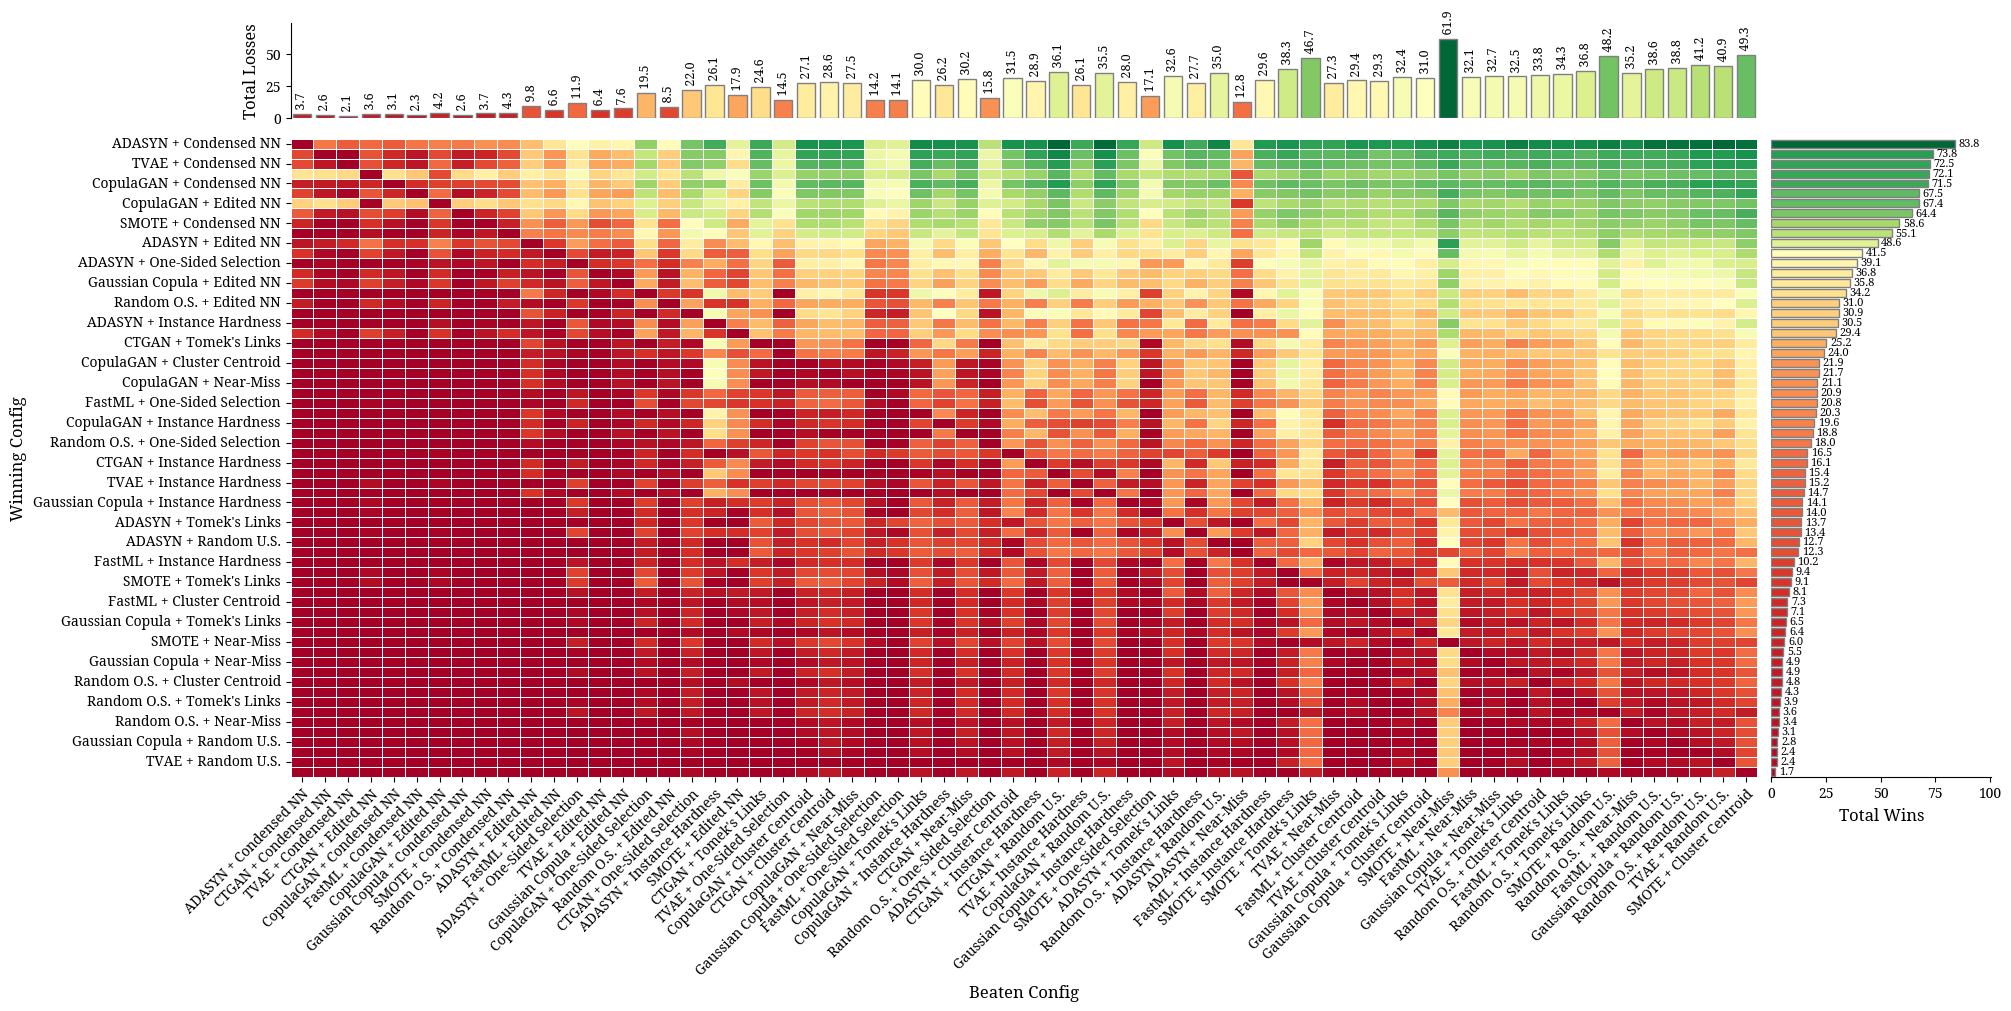


Best config overall (across all scenarios): 1 + auto threshold (Total effect size: 9.43)

Top 10 configs by total effect size:
1 + auto       9.4306
2 + auto       8.5304
1 + 0.5        7.0367
0.5 + auto     6.9580
0 + auto       6.4017
1 + 0.25       6.3713
2 + 0.5        5.9623
auto + auto    5.8820
1 + 0.125      5.8351
1 + 0.0625     5.7423
dtype: float64


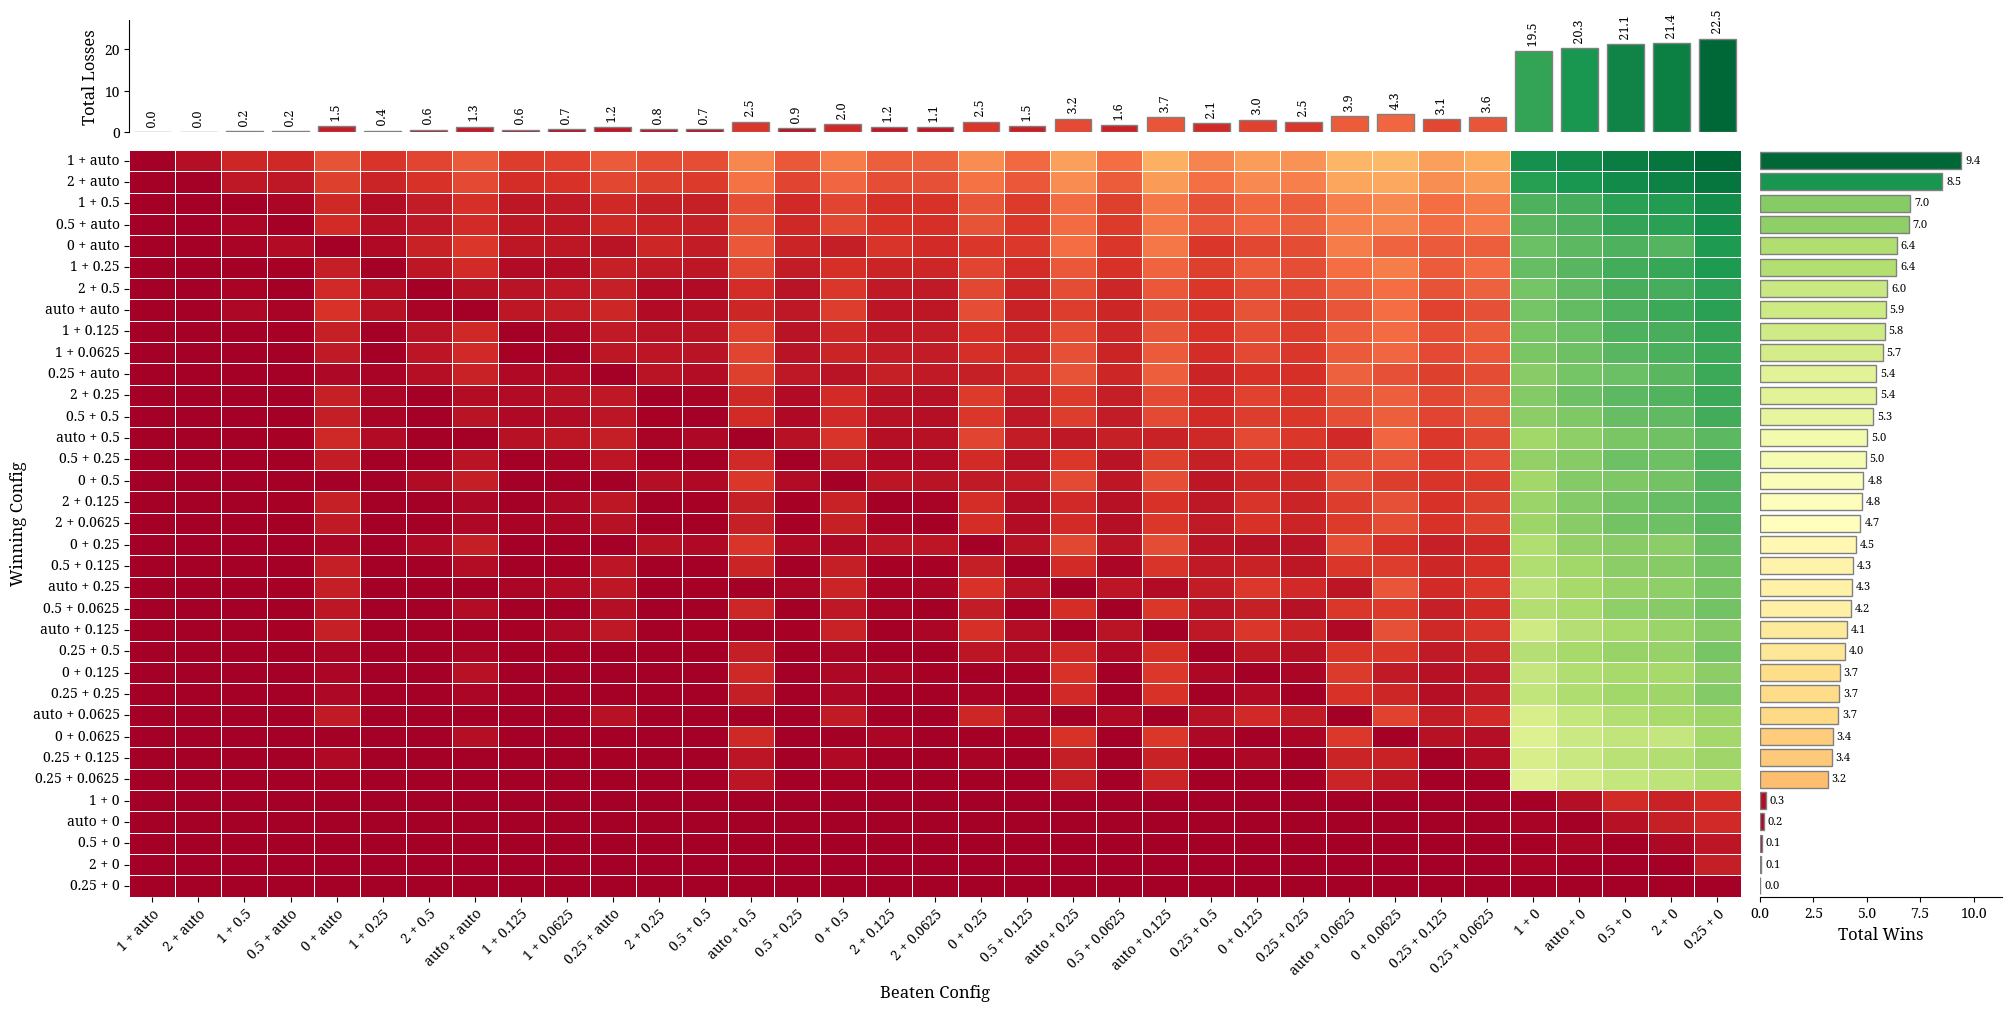

In [21]:
combined_matrix = {}
best_config = {}

for group_by in ["method", "threshold"]:
    
    # Step 1: Build and sum all win matrices
    combined_matrix[group_by] = None
    
    for scenario in datasets.keys():
        matrix = build_win_matrix_from_posthoc(
            results_by_scenario[group_by][scenario],
            mode="effect",
            ignore_significance=True
        )
    
        if combined_matrix[group_by] is None:
            combined_matrix[group_by] = matrix
        else:
            combined_matrix[group_by] = combined_matrix[group_by].add(matrix, fill_value=0)

    # Step 2: Compute totals for ALL configs (from full matrix)
    row_totals = combined_matrix[group_by].sum(axis=1)
    best_config[group_by] = row_totals.idxmax()
    best_score = row_totals.max()
    
    print(f"\nBest config overall (across all scenarios): {best_config[group_by]} {group_by} (Total effect size: {best_score:.2f})")
    print("\nTop 10 configs by total effect size:")
    print(row_totals.sort_values(ascending=False).head(10))
    
    # Step 3: Slice top-N by matrix scores, force best in
    top_n = 10
    visual_top_configs = row_totals.sort_values(ascending=False).index.tolist()
    if best_config[group_by] not in visual_top_configs:
        visual_top_configs = [best_config[group_by]] + [cfg for cfg in visual_top_configs if cfg != best_config[group_by]]
    
    # Step 4: Build final heatmap matrix
    df_top_combined = combined_matrix[group_by].loc[visual_top_configs, visual_top_configs]
    
    # Step 5: Sort rows for visual clarity
    sorted_configs = df_top_combined.sum(axis=1).sort_values(ascending=False).index.tolist()
    df_top_combined = df_top_combined.loc[sorted_configs, sorted_configs]
    
    # Step 6: Plot
    plot_win_loss_heatmap_with_marginals(
        df_top_combined,
        # title=f"Top Sampling Configs by Total Effect Size ({group_by}) (Best: {best_config[group_by]})",
        title=None,
        annot=False,
        cmap="RdYlGn",
        float_format=".1f",
        method_mapping=method_mapping,
        save_path=f"artifacts/stats/overall_{group_by}/top_sampling_configs_{group_by}s.pdf"
    )

### Pareto Frontier

In [22]:
def plot_pareto_frontier(
    df_trials,
    save_path,
    framework_mapping=None,
    top_k=None,
    normalize=True,
    log_time=False,
    use_gradient=True,
    n_clusters=None,
    highlight_markers=False,
    draw_table=False,
    show_title=False
):
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import os
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import MinMaxScaler
    from matplotlib.colors import LinearSegmentedColormap, Normalize

    def auto_kmeans(X, max_k=10):
        inertias = []
        for k in range(1, max_k + 1):
            kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
            kmeans.fit(X)
            inertias.append(kmeans.inertia_)
        diffs = np.diff(inertias)
        second_diffs = np.diff(diffs)
        best_k = np.argmax(second_diffs) + 2
        return best_k

    marker_mapping = {
        '^': ('▲', '^'),
        'D': ('♦', 'D'),
        's': ('■', 's'),
        'o': ('●', 'o')
    }

    def marker_color(label):
        return {
            'Best F1': '#ff0000',
            'Best Time': '#00ff00',
            'Best Balanced': '#0000ff'
        }.get(label, '#7f7f7f')

    df = df_trials.copy()
    if df.empty:
        print("No data provided.")
        return

    df["sampling_config"] = (
        df["oversampling_method"].astype(str) + "@" + df["oversampling_threshold"].astype(str) +
        " + " +
        df["undersampling_method"].astype(str) + "@" + df["undersampling_threshold"].astype(str)
    )

    grouped = df.groupby("sampling_config").agg({
        "value": "mean",
        "total_time": "mean"
    }).reset_index().rename(columns={"value": "F1", "total_time": "Time"})

    if log_time and not normalize:
        grouped["Time"] = np.log1p(grouped["Time"])

    if top_k is not None and top_k < len(grouped):
        grouped = grouped.sort_values("F1", ascending=False).head(top_k)

    if framework_mapping:
        grouped["sampling_config"] = grouped["sampling_config"].map(lambda x: framework_mapping.get(x, x))

    grouped["Rank_F1"] = grouped["F1"].rank(ascending=False, method="min")
    grouped["Rank_Time"] = grouped["Time"].rank(ascending=True, method="min")

    if normalize:
        grouped["Rank_F1"] = (grouped["Rank_F1"] - 1) / (grouped["Rank_F1"].max() - 1)
        grouped["Rank_Time"] = (grouped["Rank_Time"] - 1) / (grouped["Rank_Time"].max() - 1)

    grouped["Total_Rank"] = grouped["Rank_F1"] + grouped["Rank_Time"]
    grouped["Total_Rank_Pos"] = grouped["Total_Rank"].rank(method="min").astype(int)

    best_f1 = grouped.loc[grouped["Rank_F1"].idxmin()]
    best_time = grouped.loc[grouped["Rank_Time"].idxmin()]
    best_balanced = grouped.loc[grouped["Total_Rank"].idxmin()]

    best_configs = {
        best_f1["sampling_config"],
        best_time["sampling_config"],
        best_balanced["sampling_config"]
    }

    x = grouped["Rank_Time"] if normalize else grouped["Time"]
    y = grouped["Rank_F1"] if normalize else grouped["F1"]

    pareto_candidates = grouped.copy()
    pareto_candidates = pareto_candidates.sort_values("Rank_Time" if normalize else "Time", ascending=True)

    pareto_points = []
    best_y = 1.0 if normalize else -np.inf
    for _, row in pareto_candidates.iterrows():
        y_val = row["Rank_F1"] if normalize else row["F1"]
        if (normalize and y_val <= best_y) or (not normalize and y_val > best_y):
            pareto_points.append(row)
            best_y = y_val

    pareto_df = pd.DataFrame(pareto_points).sort_values("Rank_Time" if normalize else "Time", ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(19, 9))

    if use_gradient:
        scaler = MinMaxScaler()
        grouped["Gradient_Score"] = scaler.fit_transform(grouped[["Total_Rank"]])
        cmap = LinearSegmentedColormap.from_list("gradient", ["cyan", "yellow", "magenta"])
        norm = Normalize(vmin=0, vmax=1)

    coords = np.column_stack((x.values, y.values))
    k = None
    if isinstance(n_clusters, str) and n_clusters.lower() == "auto":
        print("Automatically determining optimal number of clusters...")
        k = auto_kmeans(coords)
        print(f"Optimal number of clusters: {k}")
    elif isinstance(n_clusters, int) and n_clusters > 1:
        k = n_clusters

    if k is not None:
        kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
        labels = kmeans.fit_predict(coords)
        grouped["cluster"] = labels
        cluster_sizes = grouped["cluster"].value_counts().sort_index()
        centroids = kmeans.cluster_centers_
        sizes = cluster_sizes.apply(lambda n: 100 + (n - cluster_sizes.min()) /
                                    (cluster_sizes.max() - cluster_sizes.min() + 1e-8) * (600 - 100))
        cluster_colors = (
            cmap(norm(grouped.groupby("cluster")["Gradient_Score"].mean()))
        )

        for i in range(k):
            ax.scatter(
                centroids[i, 0], centroids[i, 1],
                s=sizes[i],
                c=[cluster_colors[i]],
                edgecolors='black',
                label=None
            )
    else:
        scatter = ax.scatter(
            x, y,
            c=cmap(norm(grouped["Gradient_Score"])),
            edgecolors='black',
            s=100,
            label="All Configs"
        )

    # Always show the color bar, even if clustering is applied
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=1.0, pad=0.02)  # adjust `shrink` and `pad`
    cbar.set_label("Normalized Combined Rank: Best (0) → Worst (1)")
    cbar.ax.invert_yaxis()

    pareto_x = pareto_df["Rank_Time"] if normalize else pareto_df["Time"]
    pareto_y = pareto_df["Rank_F1"] if normalize else pareto_df["F1"]
    ax.plot(pareto_x, pareto_y, linestyle='--', color='#7f7f7f', linewidth=4, alpha=0.5, label="Pareto Frontier")
    ax.scatter(pareto_x, pareto_y, s=120, c="#7f7f7f", edgecolors='black', label="Pareto-optimal")

    def get_xy(row):
        return (
            row["Rank_Time"] if normalize else row["Time"],
            row["Rank_F1"] if normalize else row["F1"]
        )

    label_data = [
        ("Best $F_1$ Score", best_f1, '#ff0000', '^'),
        ("Best Training Time", best_time, '#00ff00', 'D'),
        ("Best Balance", best_balanced, '#0000ff', 's')
    ]

    shown_configs = set()
    summary_rows = []

    for label, row, color, marker in label_data:
        if row["sampling_config"] in shown_configs:
            continue
        x_val, y_val = get_xy(row)
        ax.scatter(
            x_val, y_val,
            s=250 if highlight_markers else 100,
            c=color,
            marker=marker,
            edgecolors='black',
            label=label
        )
        summary_rows.append({
            "Ordinal Combined Rank": int(row["Total_Rank_Pos"]),
            "Normalized Combined Rank": float(row["Total_Rank"]),
            "Label": label,
            "Marker": marker,
            "Color": color,
            "Config": row["sampling_config"]
        })
        shown_configs.add(row["sampling_config"])

    for i, (_, row) in enumerate(pareto_df.iterrows(), 1):
        if row["sampling_config"] in shown_configs:
            continue
        x_val, y_val = get_xy(row)
        ax.scatter(
            x_val, y_val,
            s=120,
            c='#7f7f7f',
            marker='o',
            edgecolors='black',
            label=None
        )
        summary_rows.append({
            "Ordinal Combined Rank": int(row["Total_Rank_Pos"]),
            "Normalized Combined Rank": float(row["Total_Rank"]),
            "Label": f"Pareto {i}",
            "Marker": 'o',
            "Color": '#7f7f7f',
            "Config": row["sampling_config"]
        })
        shown_configs.add(row["sampling_config"])

    if normalize:
        ax.set_xlabel("Training Time Rank (0 = best)")
        ax.set_ylabel("Weighted $F_1$ Score Rank (0 = best)")
        ax.invert_xaxis()
        ax.invert_yaxis()
    else:
        ax.set_xlabel("Log Time" if log_time else "Training Time")
        ax.set_ylabel("Weighted $F_1$ Score")

    if show_title:
        ax.set_title("Pareto Frontier of Sampling Configurations")
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='upper left', bbox_to_anchor=(0.0015, 0.995), borderaxespad=0.0, labelspacing=1.0)

    summary_df = pd.DataFrame(summary_rows).sort_values("Ordinal Combined Rank")

    if draw_table:
        table_data = [[" ", r["Ordinal Combined Rank"], f"{r['Normalized Combined Rank']:.4f}", r["Label"], r["Config"]] for _, r in summary_df.iterrows()]
        table = plt.table(
            cellText=table_data,
            colLabels=["", "Ordinal Combined Rank", "Normalized Combined Rank", "Label", "Config"],
            colWidths=[0.05, 0.1, 0.15, 0.25, 0.45],
            cellLoc="left",
            loc="lower center",
            bbox=[0, -0.5, 1, 0.4]
        )
        table.auto_set_font_size(False)
        table.set_fontsize(9)
    
        for cell in table.get_celld().values():
            cell.set_facecolor("white")
            if 'font_prop' in globals():
                cell.get_text().set_fontproperties(font_prop)
    
        plt.draw()
        for row_idx, row in enumerate(summary_df.itertuples(index=False), start=1):
            marker = row.Marker
            symbol = marker_mapping[marker][0]
            color = row.Color
            cell = table.get_celld()[(row_idx, 0)]
            cell.get_text().set_text(symbol)
            cell.get_text().set_color(color)
            cell.get_text().set_fontsize(16)
            cell.get_text().set_weight('bold')
            cell.get_text().set_ha('center')
            cell.get_text().set_va('center')

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.subplots_adjust(bottom=0.25)
    fig.savefig(save_path, dpi=300)
    plt.show()

    print(f"Pareto frontier saved to: {save_path}")
    return summary_df

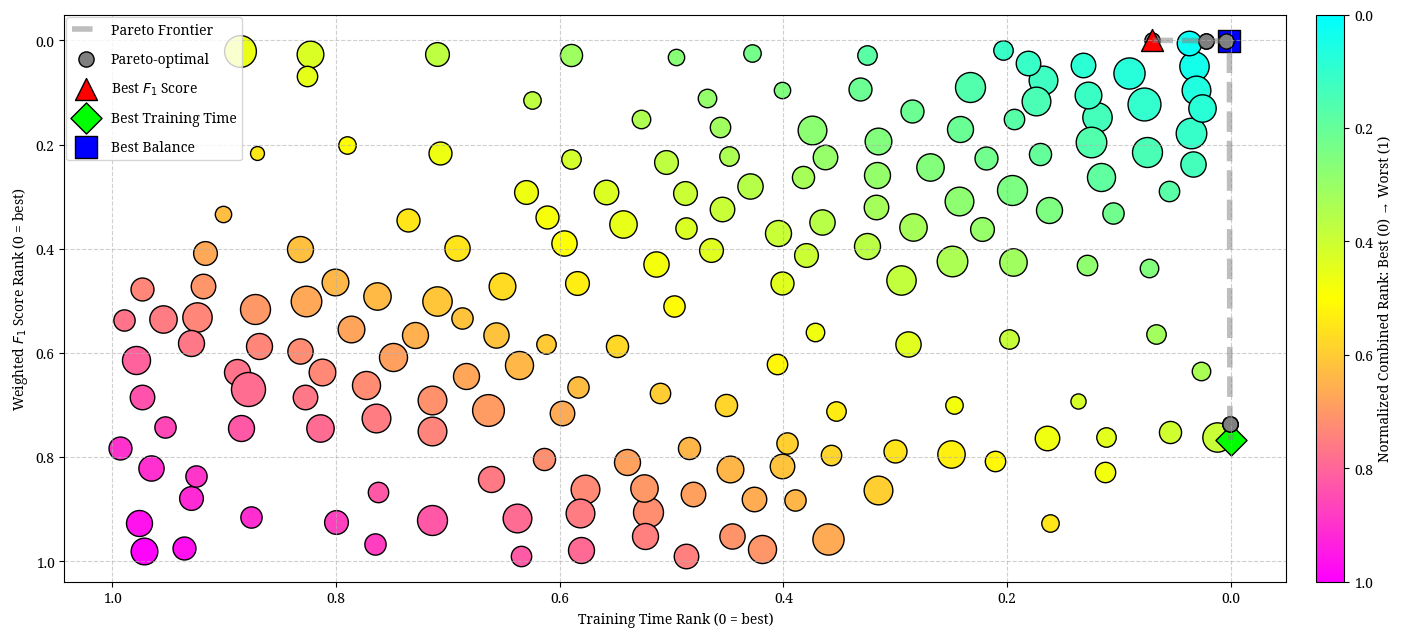

Pareto frontier saved to: artifacts/stats/pareto_frontier.pdf


,Ordinal Combined Rank,Normalized Combined Rank,Label,Marker,Color,Config
2,1,0.002682,Best Balance,s,#0000ff,adasyn@0.25 + nearmiss@auto
4,2,0.005361,Pareto 3,o,#7f7f7f,adasyn@0.25 + nearmiss@0.25
3,4,0.022779,Pareto 2,o,#7f7f7f,adasyn@0.25 + nearmiss@0.0625
0,15,0.070121,Best $F_1$ Score,^,#ff0000,adasyn@0.25 + nearmiss@0.125
6,738,0.737477,Pareto 6,o,#7f7f7f,adasyn@auto + editednn@0.25
5,739,0.737924,Pareto 5,o,#7f7f7f,adasyn@auto + editednn@0.5
1,776,0.767442,Best Training Time,D,#00ff00,copulagan@0 + editednn@auto


In [23]:
plot_pareto_frontier(
    df_trials=valid_trials_df,
    save_path="artifacts/stats/pareto_frontier.pdf",
    top_k=None,
    normalize=True,
    log_time=False,
    n_clusters=int(np.sqrt(len(valid_trials_df))),
    highlight_markers=True,
    draw_table=False,
    show_title=False
)